# AA3 · Examen del Primer Parcial · Técnica 1: Clasificación de imágenes
## Clasificación de residuos para reciclaje (cartón, vidrio, metal, papel, plástico y basura)

**Asignatura:** Aprendizaje Automático III (IN1042) · Grupo A7 · Otoño 2026
**Alumno:** Rodrigo Rosales Díaz

Se sigue la misma metodología de la Práctica 1: Keras 3 con PyTorch como backend (CUDA), pipeline dinámico por manifiesto (`pandas` + `tf.data`), EDA, y tres etapas de modelado: **CNN manual base → CNN regularizada (Data Augmentation + Dropout) → Transfer Learning con ResNet50V2**, con `EarlyStopping` y `ModelCheckpoint`, matriz de confusión y Grad-CAM.

**Problema:** en centros de acopio la separación de residuos por material se hace a mano; un residuo en el contenedor equivocado contamina el lote reciclable. El modelo recibe la foto de un residuo y predice su material.

# BLOQUE 1: VERIFICACIÓN DEL ENTORNO
## 1. Aceleración por hardware (GPU) y Keras 3 con backend PyTorch

In [1]:
import os
import torch

# Keras 3 con PyTorch como motor para usar CUDA en Windows
os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras import layers
import numpy as np

keras.utils.set_random_seed(42)

print("--- Auditoría de Hardware y Entorno ---")
print(f"Versión de Keras: {keras.__version__}")
print(f"Motor (Backend) activo en Keras: {keras.backend.backend()}")
gpu_disponible = torch.cuda.is_available()
print(f"\n¿PyTorch detecta la GPU NVIDIA (CUDA)?: {gpu_disponible}")
if gpu_disponible:
    print(f"Tarjeta Gráfica detectada: {torch.cuda.get_device_name(0)}")
else:
    print("ADVERTENCIA: No se detectó GPU.")

--- Auditoría de Hardware y Entorno ---
Versión de Keras: 3.15.1
Motor (Backend) activo en Keras: torch

¿PyTorch detecta la GPU NVIDIA (CUDA)?: True
Tarjeta Gráfica detectada: NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Control de entrenamiento: Callbacks
- **EarlyStopping:** detiene el entrenamiento si `val_loss` no mejora en 4 épocas y restaura los mejores pesos.
- **ModelCheckpoint:** guarda en disco el modelo de la mejor época.

In [2]:
os.makedirs("models", exist_ok=True)
FIG_DIR = "figuras_clasificacion"
os.makedirs(FIG_DIR, exist_ok=True)

def obtener_callbacks(nombre_experimento):
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(filepath=f"models/mejor_modelo_residuos_{nombre_experimento}.keras",
                                        save_best_only=True, monitor="val_loss", verbose=1),
    ]
print("Callbacks definidos.")

Callbacks definidos.


# BLOQUE 2: PREPARACIÓN E INGESTA DEL DATASET
## 1. Descarga: *Garbage Classification* (Kaggle)
Fotografías de residuos individuales, organizadas en una carpeta por material. Se construye un **manifiesto** (DataFrame con ruta y etiqueta) para usar el pipeline dinámico (Opción 2 de la Práctica 1).

In [3]:
import kagglehub
import pandas as pd
import tensorflow as tf
import hashlib
from sklearn.model_selection import train_test_split

print("--- Descargando dataset desde Kaggle ---")
path_dataset = kagglehub.dataset_download("asdasdasasdas/garbage-classification")
print(f"Dataset descargado en:\n{path_dataset}")

CLASES_EN = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
CLASES = ["carton", "vidrio", "metal", "papel", "plastico", "basura"]
NOMBRES_CLASES = dict(enumerate(CLASES))

filas = []
for root, _, files in os.walk(path_dataset):
    carpeta = os.path.basename(root).lower()
    if carpeta in CLASES_EN:
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                filas.append({"filepath": os.path.join(root, f), "label": CLASES_EN.index(carpeta)})
df_manifiesto = pd.DataFrame(filas)
print(f"\nImágenes encontradas: {len(df_manifiesto)}")

# Control de calidad: la descarga puede incluir copias repetidas; se eliminan duplicados exactos (hash MD5)
def md5(p):
    with open(p, "rb") as fh:
        return hashlib.md5(fh.read()).hexdigest()
df_manifiesto["md5"] = df_manifiesto["filepath"].apply(md5)
n_antes = len(df_manifiesto)
df_manifiesto = df_manifiesto.drop_duplicates("md5").reset_index(drop=True)
df_manifiesto["clase"] = df_manifiesto["label"].map(NOMBRES_CLASES)
print(f"Duplicados exactos eliminados: {n_antes - len(df_manifiesto)} | Imágenes finales: {len(df_manifiesto)}")
print(df_manifiesto[["filepath", "label", "clase"]].head())

c:\Users\rodri\OneDrive - Universidad Iberoamericana León\Clases\7to Semestre\ML III\ml3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Descargando dataset desde Kaggle ---
Dataset descargado en:
C:\Users\rodri\.cache\kagglehub\datasets\asdasdasasdas\garbage-classification\versions\2

Imágenes encontradas: 2527
Duplicados exactos eliminados: 3 | Imágenes finales: 2524
                                            filepath  label   clase
0  C:\Users\rodri\.cache\kagglehub\datasets\asdas...      0  carton
1  C:\Users\rodri\.cache\kagglehub\datasets\asdas...      0  carton
2  C:\Users\rodri\.cache\kagglehub\datasets\asdas...      0  carton
3  C:\Users\rodri\.cache\kagglehub\datasets\asdas...      0  carton
4  C:\Users\rodri\.cache\kagglehub\datasets\asdas...      0  carton


## 2. División estratificada (70 % / 15 % / 15 %) y pipeline dinámico `tf.data`

In [4]:
train_df, val_test_df = train_test_split(df_manifiesto, test_size=0.30, random_state=42, stratify=df_manifiesto["label"])
val_df, test_df = train_test_split(val_test_df, test_size=0.50, random_state=42, stratify=val_test_df["label"])
print(f"Muestras de Entrenamiento: {len(train_df)}")
print(f"Muestras de Validación:   {len(val_df)}")
print(f"Muestras de Test:         {len(test_df)}")

IMG_SIZE = 224
BATCH_SIZE = 32

def procesar_ruta_imagen(filepath, label):
    img_bytes = tf.io.read_file(filepath)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, label

def crear_pipeline_tfdata(df, es_entrenamiento=False):
    dataset = tf.data.Dataset.from_tensor_slices((df["filepath"].values, df["label"].values))
    dataset = dataset.map(procesar_ruta_imagen, num_parallel_calls=tf.data.AUTOTUNE)
    if es_entrenamiento:
        dataset = dataset.shuffle(buffer_size=1000, seed=42)
    return dataset.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

train_dataset = crear_pipeline_tfdata(train_df, es_entrenamiento=True)
val_dataset = crear_pipeline_tfdata(val_df)
test_dataset = crear_pipeline_tfdata(test_df)
print("\nPipelines de datos generados con Prefetch.")

Muestras de Entrenamiento: 1766
Muestras de Validación:   379
Muestras de Test:         379

Pipelines de datos generados con Prefetch.


## 3. Análisis exploratorio de datos (EDA)

Total de imágenes: 2524

   Clase  Total Imágenes  Porcentaje (%)
  carton             403           15.97
  vidrio             501           19.85
   metal             409           16.20
   papel             594           23.53
plastico             480           19.02
  basura             137            5.43

--- Partición por clase ---
          Entrenamiento  Validación  Prueba
clase                                      
carton              282          61      60
vidrio              350          75      76
metal               286          62      61
papel               416          89      89
plastico            336          72      72
basura               96          20      21
TOTAL              1766         379     379


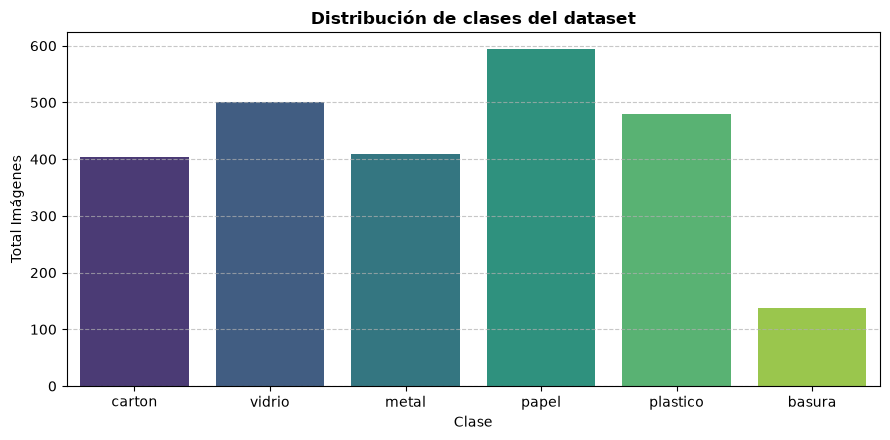

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

dist = df_manifiesto["clase"].value_counts().reindex(CLASES)
df_dist = pd.DataFrame({"Clase": dist.index, "Total Imágenes": dist.values,
                        "Porcentaje (%)": np.round(dist.values / len(df_manifiesto) * 100, 2)})
print(f"Total de imágenes: {len(df_manifiesto)}\n")
print(df_dist.to_string(index=False))

particion = pd.concat({"Entrenamiento": train_df["clase"].value_counts(), "Validación": val_df["clase"].value_counts(),
                       "Prueba": test_df["clase"].value_counts()}, axis=1).reindex(CLASES)
particion.loc["TOTAL"] = particion.sum()
print("\n--- Partición por clase ---")
print(particion.to_string())

plt.figure(figsize=(9, 4.5))
sns.barplot(x=df_dist["Clase"], y=df_dist["Total Imágenes"], hue=df_dist["Clase"], palette="viridis", legend=False)
plt.title("Distribución de clases del dataset", fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/distribucion_clases.png", dpi=150); plt.show()

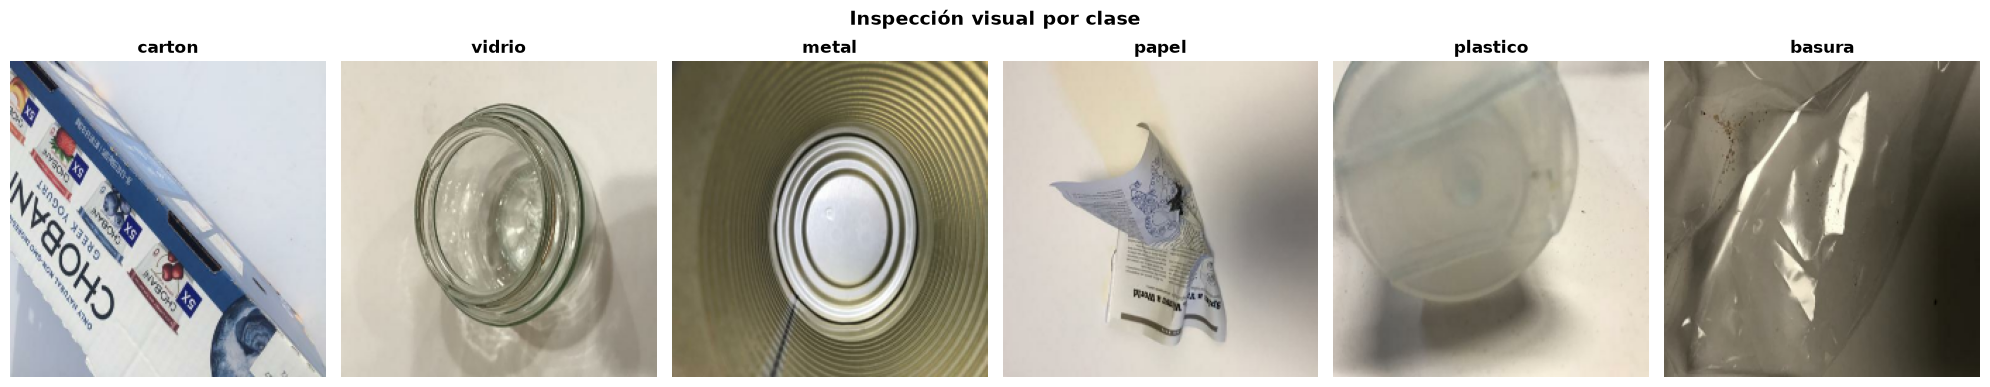

In [6]:
# Inspección visual: una muestra por clase
fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for i, c in enumerate(CLASES):
    muestra = df_manifiesto[df_manifiesto["label"] == i].sample(1, random_state=42).iloc[0]
    img, _ = procesar_ruta_imagen(muestra["filepath"], 0)
    axes[i].imshow(img.numpy().astype("uint8")); axes[i].set_title(c, fontweight="bold"); axes[i].axis("off")
plt.suptitle("Inspección visual por clase", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/ejemplos_por_clase.png", dpi=150); plt.show()

In [7]:
# Validación del pipeline: anatomía de un lote
for lote_imagenes, lote_etiquetas in train_dataset.take(1):
    print(f"Forma del tensor de imágenes (Batch, Alto, Ancho, Canales): {lote_imagenes.shape}")
    print(f"Forma del tensor de etiquetas: {lote_etiquetas.shape}")
    print(f"Primeras 8 etiquetas del lote: {lote_etiquetas.numpy()[:8]}")
    break

Forma del tensor de imágenes (Batch, Alto, Ancho, Canales): (32, 224, 224, 3)
Forma del tensor de etiquetas: (32,)
Primeras 8 etiquetas del lote: [0 1 3 2 3 3 1 1]


# BLOQUE 3: CNN MANUAL BASE (sin regularizar)
Arquitectura piramidal con API Funcional: `Rescaling` → 3 bloques Conv2D (32→64→128) + MaxPooling → Flatten → Dense(64) → **Dense(6, softmax)**. Al ser 6 clases se usa `softmax` y `sparse_categorical_crossentropy` (en la Práctica 1 era binario con `sigmoid`).

In [8]:
NUM_CLASES = len(CLASES)

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="Input_Residuo")
x = layers.Rescaling(1./255, name="Normalizacion_Pixeles")(inputs)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="Conv_1")(x)
x = layers.MaxPooling2D((2, 2), name="Max_Pool_1")(x)
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="Conv_2")(x)
x = layers.MaxPooling2D((2, 2), name="Max_Pool_2")(x)
x = layers.Conv2D(128, (3, 3), activation="relu", padding="same", name="Conv_3")(x)
x = layers.MaxPooling2D((2, 2), name="Max_Pool_3")(x)
x = layers.Flatten(name="Aplanado_Volumen")(x)
x = layers.Dense(64, activation="relu", name="Capa_Densa_Intermedia")(x)
outputs = layers.Dense(NUM_CLASES, activation="softmax", name="Clase_Residuo")(x)
model_manual_base = keras.Model(inputs, outputs, name="CNN_Manual_Base")

model_manual_base.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                          loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_manual_base.summary()

Model: "CNN_Manual_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Residuo (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Normalizacion_Pixeles           │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_1 (MaxPooling2D)       │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_2 (MaxPooling2D)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_3 (MaxPooling2D)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado_Volumen (Flatten)      │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Densa_Intermedia (Dense)   │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Clase_Residuo (Dense)           │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,230 (24.86 MB)

 Trainable params: 6,516,230 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
print("--- Iniciando Entrenamiento de la CNN Manual Base ---")
history_manual_base = model_manual_base.fit(train_dataset, epochs=15, validation_data=val_dataset,
                                            callbacks=obtener_callbacks("manual_base"))

--- Iniciando Entrenamiento de la CNN Manual Base ---


c:\Users\rodri\OneDrive - Universidad Iberoamericana León\Clases\7to Semestre\ML III\ml3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/15
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3443 - loss: 1.6382
Epoch 1: val_loss improved from None to 1.36286, saving model to models/mejor_modelo_residuos_manual_base.keras

Epoch 1: finished saving model to models/mejor_modelo_residuos_manual_base.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.3431 - loss: 1.6379 - val_accuracy: 0.4617 - val_loss: 1.3629
Epoch 2/15
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4960 - loss: 1.2878
Epoch 2: val_loss improved from 1.36286 to 1.26348, saving model to models/mejor_modelo_residuos_manual_base.keras

Epoch 2: finished saving model to models/mejor_modelo_residuos_manual_base.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.4949 - loss: 1.2880 - val_accuracy: 0.4749 - val_loss: 1.2635
Epoch 3/15
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6040 - loss: 1.0855
Epoch 3: val_loss improved from 1.26348 to 1.16692, saving model to models/mejor_modelo_residuos_manual_base.keras

Epoch 

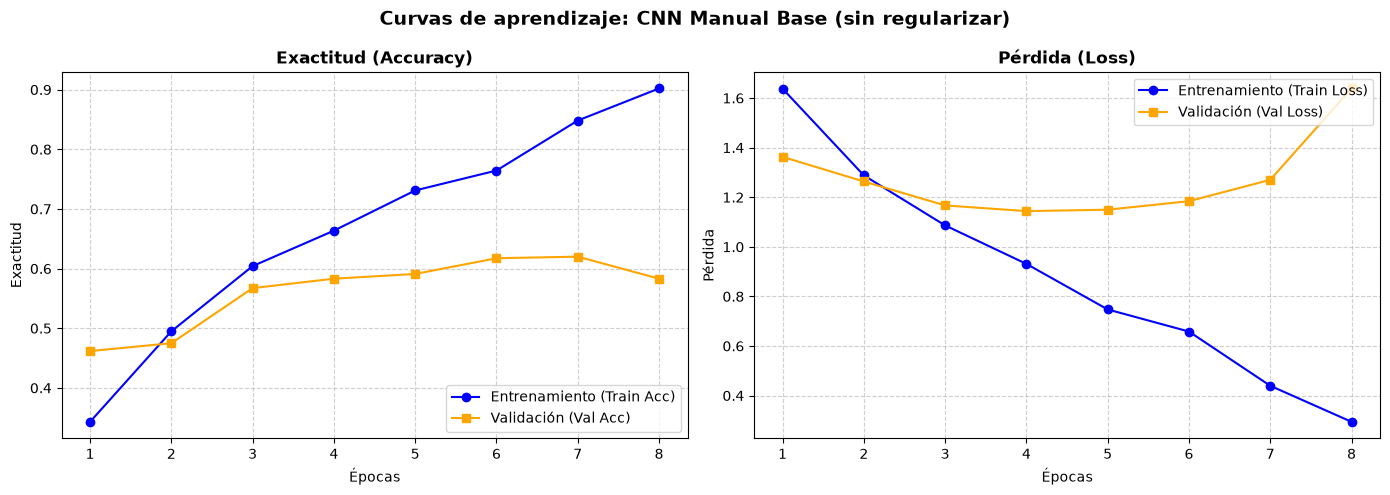

In [10]:
def graficar_curvas(history, titulo, archivo, c1="blue", c2="orange"):
    acc, val_acc = history.history["accuracy"], history.history["val_accuracy"]
    loss, val_loss = history.history["loss"], history.history["val_loss"]
    ep = range(1, len(acc) + 1)
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(ep, acc, label="Entrenamiento (Train Acc)", marker="o", color=c1)
    plt.plot(ep, val_acc, label="Validación (Val Acc)", marker="s", color=c2)
    plt.title("Exactitud (Accuracy)", fontweight="bold"); plt.xlabel("Épocas"); plt.ylabel("Exactitud")
    plt.legend(loc="lower right"); plt.grid(True, linestyle="--", alpha=0.6)
    plt.subplot(1, 2, 2)
    plt.plot(ep, loss, label="Entrenamiento (Train Loss)", marker="o", color=c1)
    plt.plot(ep, val_loss, label="Validación (Val Loss)", marker="s", color=c2)
    plt.title("Pérdida (Loss)", fontweight="bold"); plt.xlabel("Épocas"); plt.ylabel("Pérdida")
    plt.legend(loc="upper right"); plt.grid(True, linestyle="--", alpha=0.6)
    plt.suptitle(titulo, fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/{archivo}", dpi=150); plt.show()

graficar_curvas(history_manual_base, "Curvas de aprendizaje: CNN Manual Base (sin regularizar)", "curvas_base.png")

=== RENDIMIENTO EN TEST SET: CNN Manual Base ===
Pérdida (Test Loss):  1.1396
Exactitud (Accuracy): 59.63%
F1 macro:             0.5747

              precision    recall  f1-score   support

      carton     0.6447    0.8167    0.7206        60
      vidrio     0.4851    0.6447    0.5537        76
       metal     0.4894    0.3770    0.4259        61
       papel     0.7465    0.5955    0.6625        89
    plastico     0.7455    0.5694    0.6457        72
      basura     0.3793    0.5238    0.4400        21

    accuracy                         0.5963       379
   macro avg     0.5817    0.5879    0.5747       379
weighted avg     0.6160    0.5963    0.5963       379



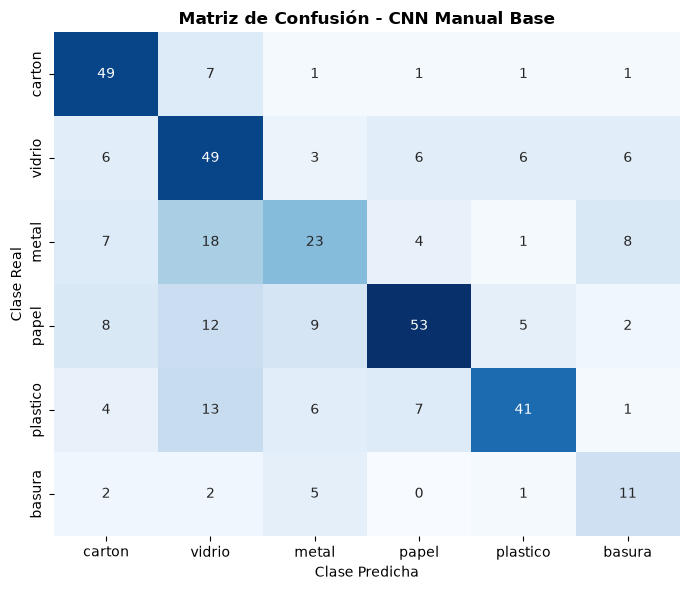

In [11]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score

def evaluar_modelo(modelo, nombre, cmap, archivo):
    loss_test, acc_test = modelo.evaluate(test_dataset, verbose=0)
    y_true, y_prob = [], []
    for lote_img, lote_lbl in test_dataset:
        y_prob.append(modelo.predict(lote_img, verbose=0))
        y_true.extend(lote_lbl.numpy())
    y_true, y_prob = np.array(y_true), np.concatenate(y_prob)
    y_pred = y_prob.argmax(axis=1)
    f1m = f1_score(y_true, y_pred, average="macro")

    print(f"=== RENDIMIENTO EN TEST SET: {nombre} ===")
    print(f"Pérdida (Test Loss):  {loss_test:.4f}")
    print(f"Exactitud (Accuracy): {acc_test * 100:.2f}%")
    print(f"F1 macro:             {f1m:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=CLASES, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, cbar=False, xticklabels=CLASES, yticklabels=CLASES)
    plt.title(f"Matriz de Confusión - {nombre}", fontweight="bold")
    plt.xlabel("Clase Predicha"); plt.ylabel("Clase Real")
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/{archivo}", dpi=150); plt.show()
    return dict(loss=loss_test, acc=acc_test, f1=f1m, y_true=y_true, y_prob=y_prob, y_pred=y_pred)

res_base = evaluar_modelo(model_manual_base, "CNN Manual Base", "Blues", "matriz_base.png")

# BLOQUE 4: REGULARIZACIÓN (Data Augmentation + Dropout)
Transformaciones geométricas aleatorias (volteos, rotación y zoom leves) y `Dropout(0.4)` antes de la cabeza densa. Keras las activa solo durante `fit()`.

In [12]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", name="Volteo_Aleatorio"),
    layers.RandomRotation(0.08, fill_mode="nearest", name="Rotacion_Leve"),
    layers.RandomZoom(0.08, fill_mode="nearest", name="Zoom_Leve"),
], name="Pipeline_Data_Augmentation")

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="Input_Residuo")
x = data_augmentation(inputs)
x = layers.Rescaling(1./255, name="Normalizacion_Pixeles")(x)
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="Conv_1")(x)
x = layers.MaxPooling2D((2, 2), name="Max_Pool_1")(x)
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="Conv_2")(x)
x = layers.MaxPooling2D((2, 2), name="Max_Pool_2")(x)
x = layers.Conv2D(128, (3, 3), activation="relu", padding="same", name="Conv_3")(x)
x = layers.MaxPooling2D((2, 2), name="Max_Pool_3")(x)
x = layers.Flatten(name="Aplanado_Volumen")(x)
x = layers.Dropout(0.4, name="Regularizacion_Dropout")(x)
x = layers.Dense(64, activation="relu", name="Capa_Densa_Intermedia")(x)
outputs = layers.Dense(NUM_CLASES, activation="softmax", name="Clase_Residuo")(x)
model_manual_regularizado = keras.Model(inputs, outputs, name="CNN_Manual_Regularizada")

model_manual_regularizado.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_manual_regularizado.summary()

Model: "CNN_Manual_Regularizada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Residuo (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pipeline_Data_Augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Normalizacion_Pixeles           │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_1 (MaxPooling2D)       │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_2 (MaxPooling2D)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_3 (MaxPooling2D)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado_Volumen (Flatten)      │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Regularizacion_Dropout          │ (None, 100352)         │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Densa_Intermedia (Dense)   │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Clase_Residuo (Dense)           │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,230 (24.86 MB)

 Trainable params: 6,516,230 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

--- Iniciando Entrenamiento de la CNN Manual Regularizada ---


c:\Users\rodri\OneDrive - Universidad Iberoamericana León\Clases\7to Semestre\ML III\ml3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/15
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.2761 - loss: 1.9893
Epoch 1: val_loss improved from None to 1.52957, saving model to models/mejor_modelo_residuos_manual_regularizado.keras

Epoch 1: finished saving model to models/mejor_modelo_residuos_manual_regularizado.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 200ms/step - accuracy: 0.2752 - loss: 1.9889 - val_accuracy: 0.3456 - val_loss: 1.5296
Epoch 2/15
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.3926 - loss: 1.4702
Epoch 2: val_loss improved from 1.52957 to 1.36787, saving model to models/mejor_modelo_residuos_manual_regularizado.keras

Epoch 2: finished saving model to models/mejor_modelo_residuos_manual_regularizado.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.3930 - loss: 1.4704 - val_accuracy: 0.4195 - val_loss: 1.3679
Epoch 3/15
55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.4352 - loss: 1.3575
Epoch 3: val_loss improved from 1.36787 to 1.27346, saving model to models/mejor_mo

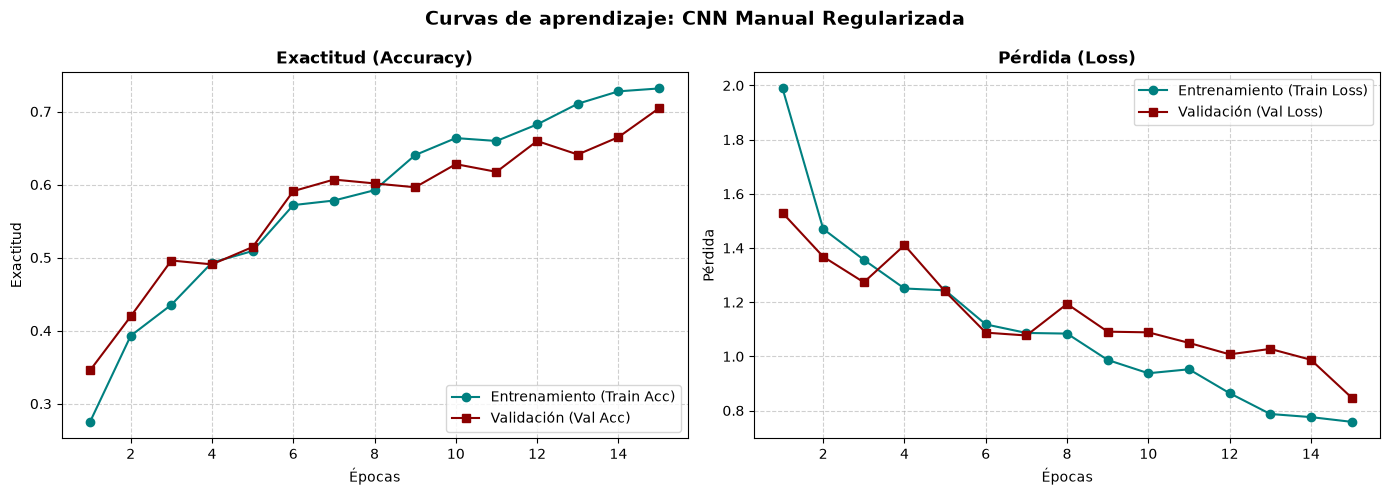

In [13]:
print("--- Iniciando Entrenamiento de la CNN Manual Regularizada ---")
history_manual_regularizado = model_manual_regularizado.fit(train_dataset, epochs=15, validation_data=val_dataset,
                                                            callbacks=obtener_callbacks("manual_regularizado"))
graficar_curvas(history_manual_regularizado, "Curvas de aprendizaje: CNN Manual Regularizada", "curvas_regularizada.png", "teal", "darkred")

=== RENDIMIENTO EN TEST SET: CNN Manual Regularizada ===
Pérdida (Test Loss):  0.8632
Exactitud (Accuracy): 71.77%
F1 macro:             0.6903

              precision    recall  f1-score   support

      carton     0.7910    0.8833    0.8346        60
      vidrio     0.7581    0.6184    0.6812        76
       metal     0.6140    0.5738    0.5932        61
       papel     0.7600    0.8539    0.8042        89
    plastico     0.7101    0.6806    0.6950        72
      basura     0.5000    0.5714    0.5333        21

    accuracy                         0.7177       379
   macro avg     0.6889    0.6969    0.6903       379
weighted avg     0.7172    0.7177    0.7147       379



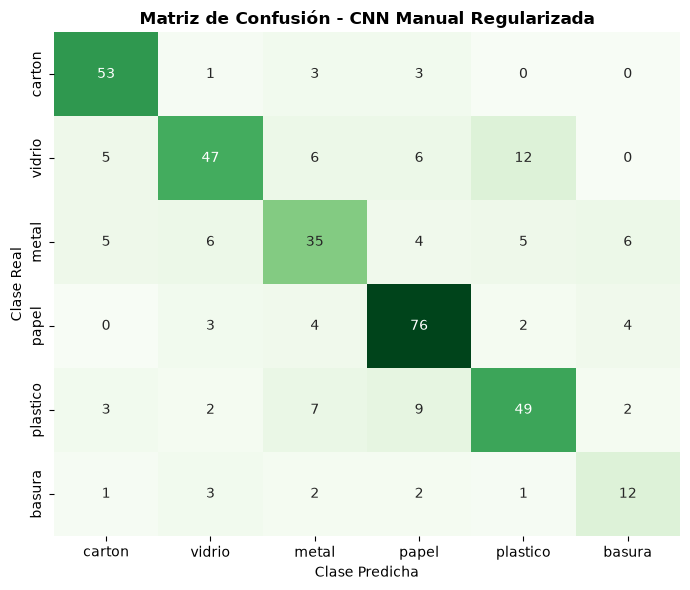

In [14]:
res_reg = evaluar_modelo(model_manual_regularizado, "CNN Manual Regularizada", "Greens", "matriz_regularizada.png")

# BLOQUE 5: TRANSFER LEARNING CON RESNET50V2
Esqueleto ResNet50V2 preentrenado en ImageNet **congelado** (`base_model.trainable = False`), preprocesamiento nativo (`resnet_v2.preprocess_input`), `GlobalAveragePooling2D`, `Dropout(0.3)` y una capa densa de 6 clases.
Se inserta desde el inicio la **capa de identidad** `Identity_Feature_Map` (Bloque 6 de la Práctica 1) para poder aplicar Grad-CAM sobre este mismo modelo entrenado.

In [15]:
base_model = keras.applications.ResNet50V2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False
preprocess_input = keras.applications.resnet_v2.preprocess_input

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="Input_Residuo")
x = data_augmentation(inputs)
x = preprocess_input(x)
x_conv = base_model(x, training=False)
identity_conv = layers.Activation("linear", name="Identity_Feature_Map")(x_conv)
x = layers.GlobalAveragePooling2D(name="Compactacion_Espacial")(identity_conv)
x = layers.Dropout(0.3, name="Regularizacion_Cabeza")(x)
outputs = layers.Dense(NUM_CLASES, activation="softmax", name="Clase_Residuo_Transfer")(x)
model_transfer = keras.Model(inputs, outputs, name="CNN_ResNet50V2_Transfer")

model_transfer.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                       loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_transfer.summary()

Model: "CNN_ResNet50V2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Residuo (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pipeline_Data_Augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Identity_Feature_Map            │ (None, 7, 7, 2048)     │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Compactacion_Espacial           │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Regularizacion_Cabeza (Dropout) │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Clase_Residuo_Transfer (Dense)  │ (None, 6)              │        12,294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,577,094 (89.94 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

--- Iniciando Entrenamiento con Transfer Learning (ResNet50V2) ---


c:\Users\rodri\OneDrive - Universidad Iberoamericana León\Clases\7to Semestre\ML III\ml3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.5583 - loss: 1.2019
Epoch 1: val_loss improved from None to 0.66734, saving model to models/mejor_modelo_residuos_transfer_resnet50v2.keras

Epoch 1: finished saving model to models/mejor_modelo_residuos_transfer_resnet50v2.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 260ms/step - accuracy: 0.5583 - loss: 1.2019 - val_accuracy: 0.7599 - val_loss: 0.6673
Epoch 2/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7384 - loss: 0.7028
Epoch 2: val_loss improved from 0.66734 to 0.61737, saving model to models/mejor_modelo_residuos_transfer_resnet50v2.keras

Epoch 2: finished saving model to models/mejor_modelo_residuos_transfer_resnet50v2.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 252ms/step - accuracy: 0.7384 - loss: 0.7028 - val_accuracy: 0.7652 - val_loss: 0.6174
Epoch 3/8
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.8137 - loss: 0.5470
Epoch 3: val_loss improved from 0.61737 to 0.54018, saving model to models/mejor_model

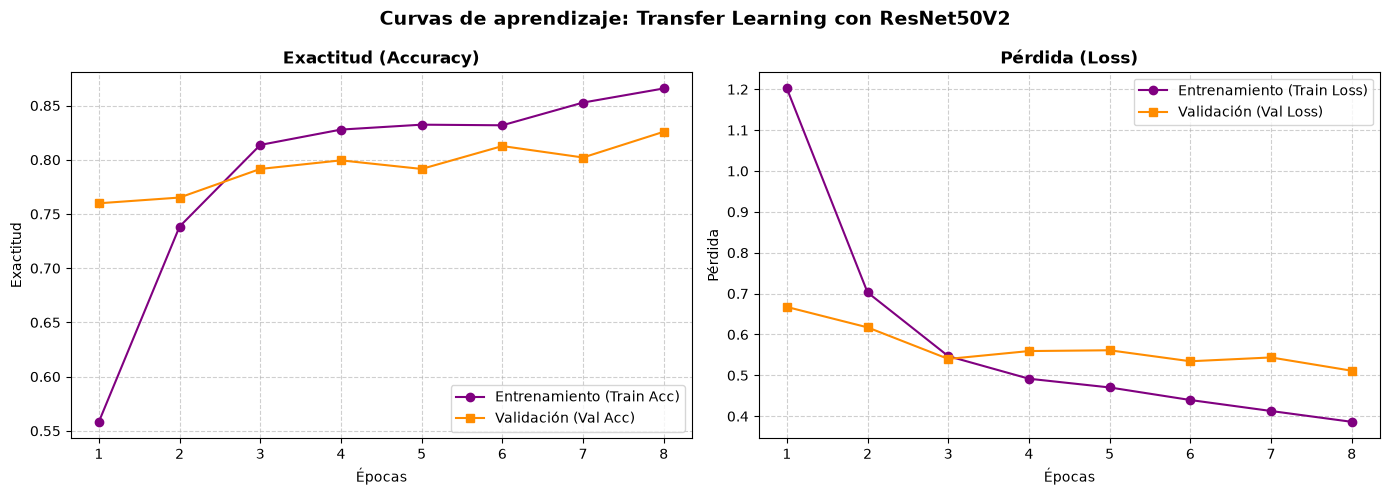

In [16]:
print("--- Iniciando Entrenamiento con Transfer Learning (ResNet50V2) ---")
history_transfer = model_transfer.fit(train_dataset, epochs=8, validation_data=val_dataset,
                                      callbacks=obtener_callbacks("transfer_resnet50v2"))
graficar_curvas(history_transfer, "Curvas de aprendizaje: Transfer Learning con ResNet50V2", "curvas_resnet50v2.png", "purple", "darkorange")

=== RENDIMIENTO EN TEST SET: ResNet50V2 Transfer Learning ===
Pérdida (Test Loss):  0.4325
Exactitud (Accuracy): 83.91%
F1 macro:             0.8157

              precision    recall  f1-score   support

      carton     0.9138    0.8833    0.8983        60
      vidrio     0.8889    0.7368    0.8058        76
       metal     0.6923    0.8852    0.7770        61
       papel     0.9011    0.9213    0.9111        89
    plastico     0.8243    0.8472    0.8356        72
      basura     0.8000    0.5714    0.6667        21

    accuracy                         0.8391       379
   macro avg     0.8367    0.8076    0.8157       379
weighted avg     0.8469    0.8391    0.8385       379



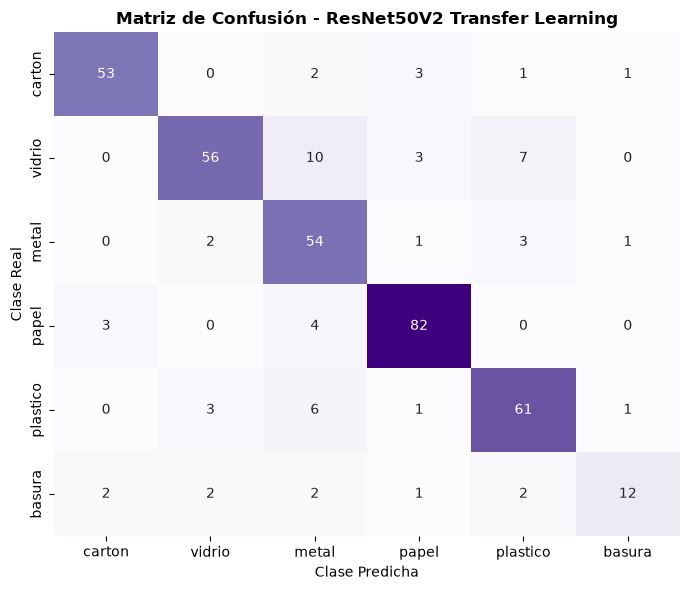

In [17]:
res_tf = evaluar_modelo(model_transfer, "ResNet50V2 Transfer Learning", "Purples", "matriz_resnet50v2.png")

## Gran tabla comparativa de los tres modelos (conjunto de prueba)

In [18]:
tabla = pd.DataFrame({
    "Bloque 3: Base":         [res_base["acc"] * 100, res_base["f1"], res_base["loss"], len(history_manual_base.history["loss"])],
    "Bloque 4: Regularizado": [res_reg["acc"] * 100, res_reg["f1"], res_reg["loss"], len(history_manual_regularizado.history["loss"])],
    "Bloque 5: ResNet50V2":   [res_tf["acc"] * 100, res_tf["f1"], res_tf["loss"], len(history_transfer.history["loss"])],
}, index=["Exactitud (%)", "F1 macro", "Pérdida (test)", "Épocas ejecutadas"]).round(4)
tabla

,Bloque 3: Base,Bloque 4: Regularizado,Bloque 5: ResNet50V2
Exactitud (%),59.6306,71.7678,83.9050
F1 macro,0.5747,0.6903,0.8157
Pérdida (test),1.1396,0.8632,0.4325
Épocas ejecutadas,8.0000,15.0000,8.0000


## Capturas de predicciones sobre el conjunto de prueba (ResNet50V2)

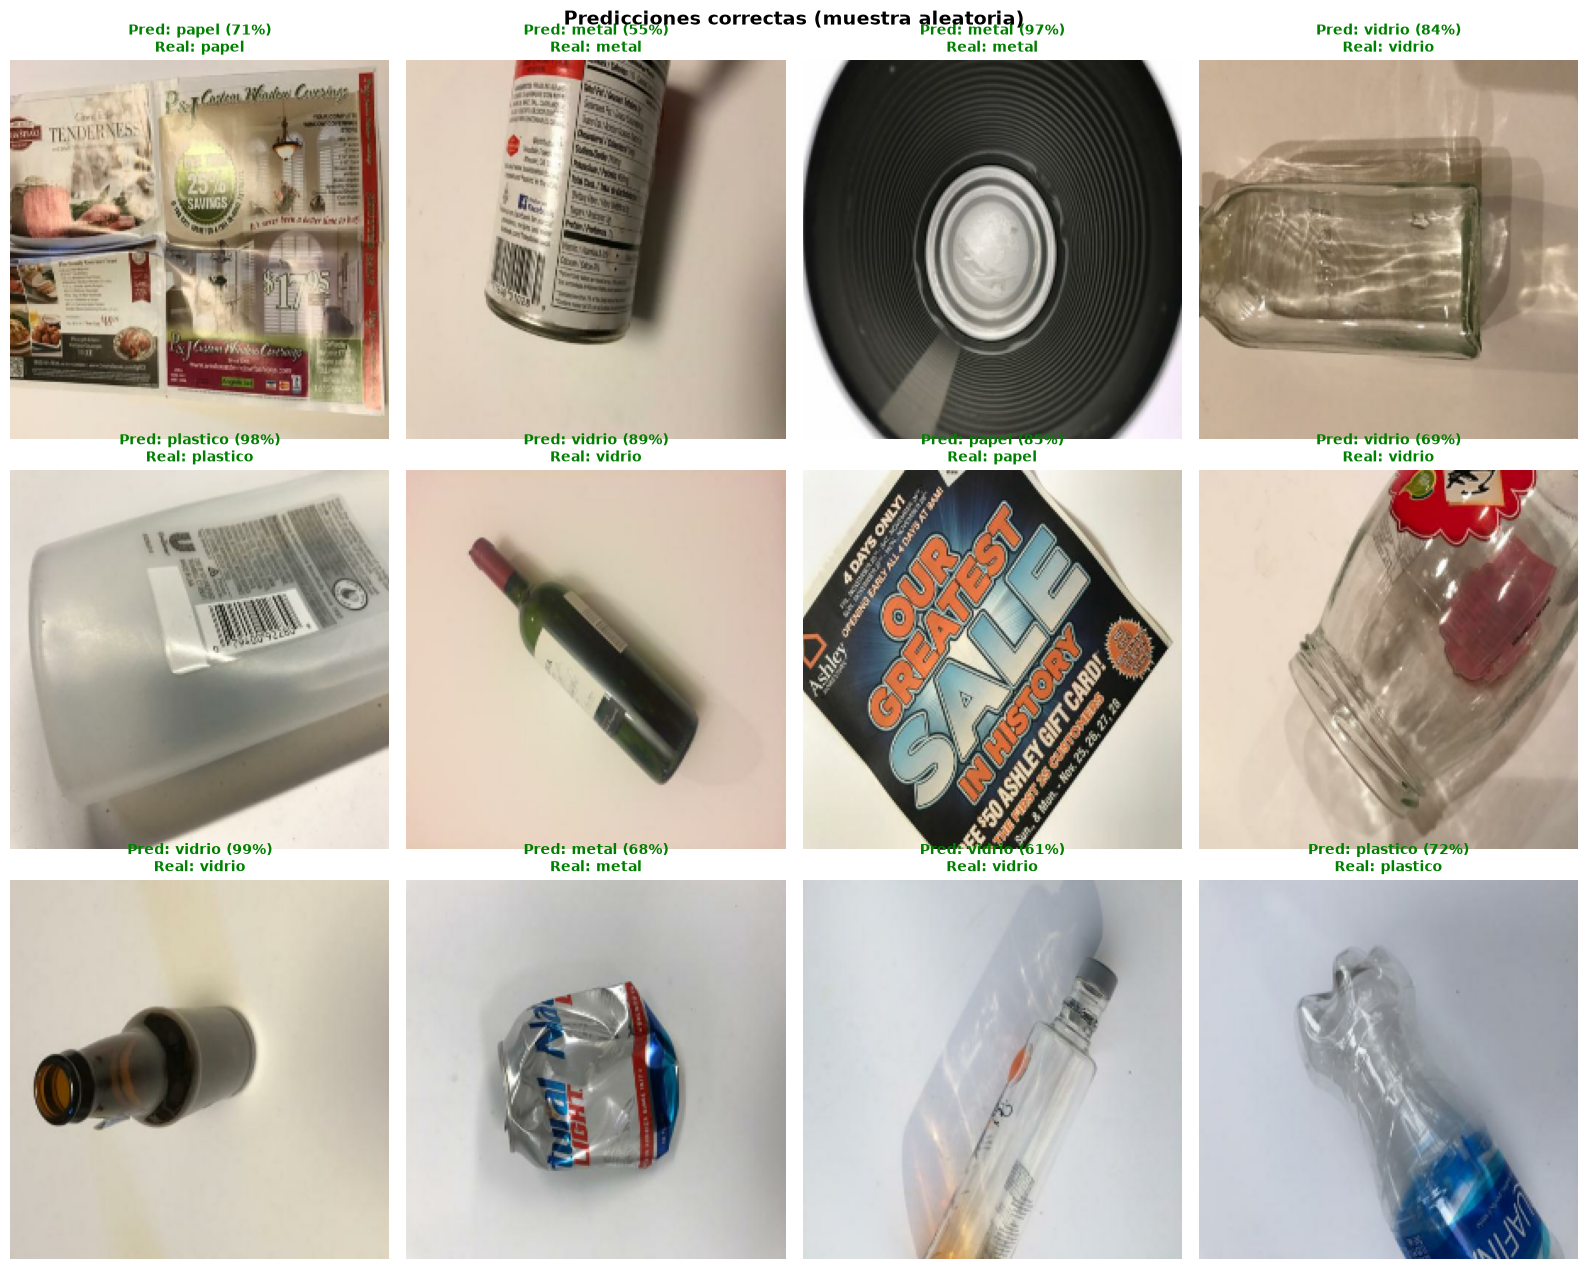

Errores en prueba: 61


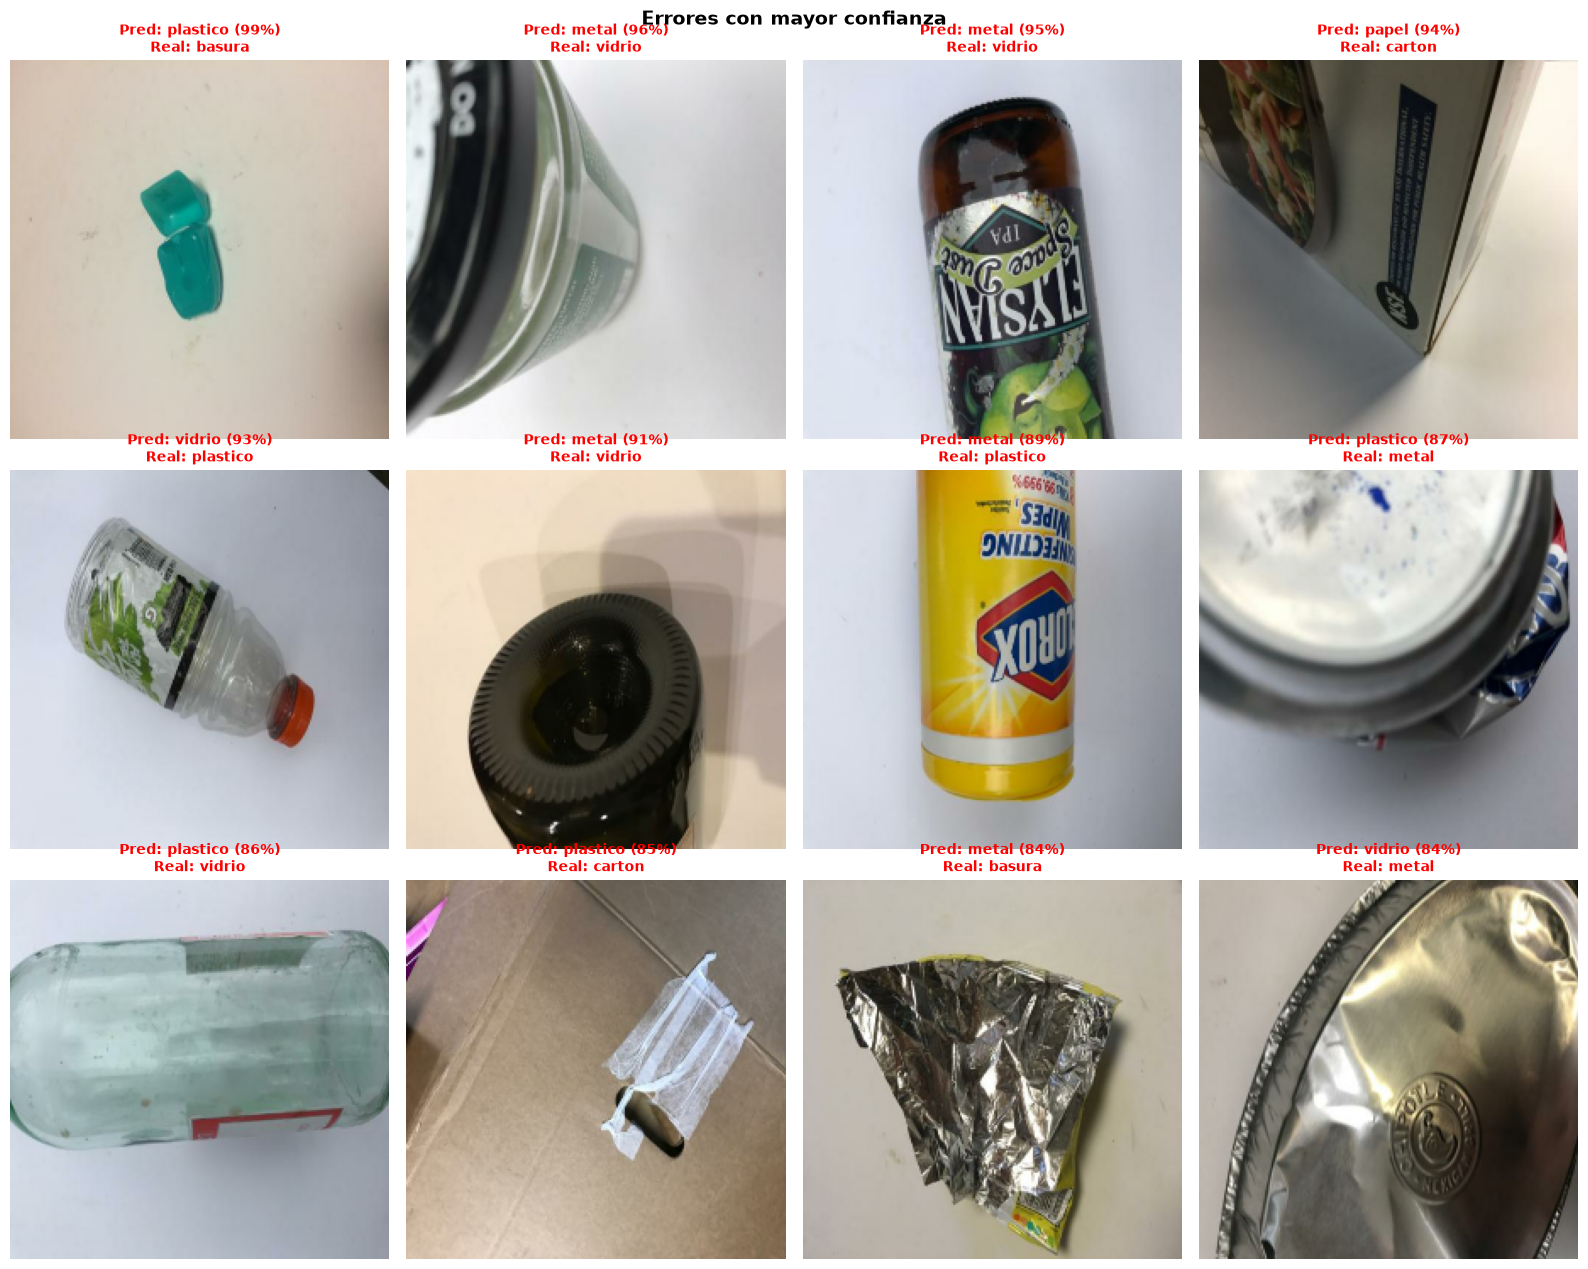

vidrio → metal       10
vidrio → plastico     7
plastico → metal      6
papel → metal         4
vidrio → papel        3
plastico → vidrio     3
papel → carton        3
carton → papel        3
metal → plastico      3
carton → metal        2
Name: casos, dtype: int64

In [19]:
test_imgs = np.concatenate([lote.numpy() for lote, _ in test_dataset])
y_true, y_prob, y_pred = res_tf["y_true"], res_tf["y_prob"], res_tf["y_pred"]
conf = y_prob.max(axis=1)

def rejilla_predicciones(indices, titulo, archivo):
    indices = list(indices)[:12]
    if not indices:
        print("Sin ejemplos para:", titulo); return
    filas = int(np.ceil(len(indices) / 4))
    fig, axes = plt.subplots(filas, 4, figsize=(16, 4.3 * filas))
    for ax in np.array(axes).ravel(): ax.axis("off")
    for ax, i in zip(np.array(axes).ravel(), indices):
        ax.imshow(test_imgs[i].astype("uint8"))
        ok = y_pred[i] == y_true[i]
        ax.set_title(f"Pred: {CLASES[y_pred[i]]} ({conf[i]*100:.0f}%)\nReal: {CLASES[y_true[i]]}",
                     color="green" if ok else "red", fontweight="bold", fontsize=10)
    plt.suptitle(titulo, fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/{archivo}", dpi=150); plt.show()

rng = np.random.default_rng(42)
aciertos = np.where(y_pred == y_true)[0]
errores = np.where(y_pred != y_true)[0]
rejilla_predicciones(rng.choice(aciertos, size=min(12, len(aciertos)), replace=False), "Predicciones correctas (muestra aleatoria)", "predicciones_aciertos.png")
print("Errores en prueba:", len(errores))
rejilla_predicciones(errores[np.argsort(-conf[errores])], "Errores con mayor confianza", "predicciones_errores.png")

pd.Series([f"{CLASES[a]} → {CLASES[b]}" for a, b in zip(y_true[errores], y_pred[errores])]).value_counts().head(10).rename("casos")

# BLOQUE 6: EXPLICABILIDAD CON GRAD-CAM
Mismo algoritmo de la Práctica 1: se extraen las activaciones de `Identity_Feature_Map` (7×7×2048), se calcula el gradiente del puntaje de la **clase predicha** con el autograd de PyTorch, se promedian los gradientes por canal (pesos α), se combinan las activaciones y se aplica ReLU.

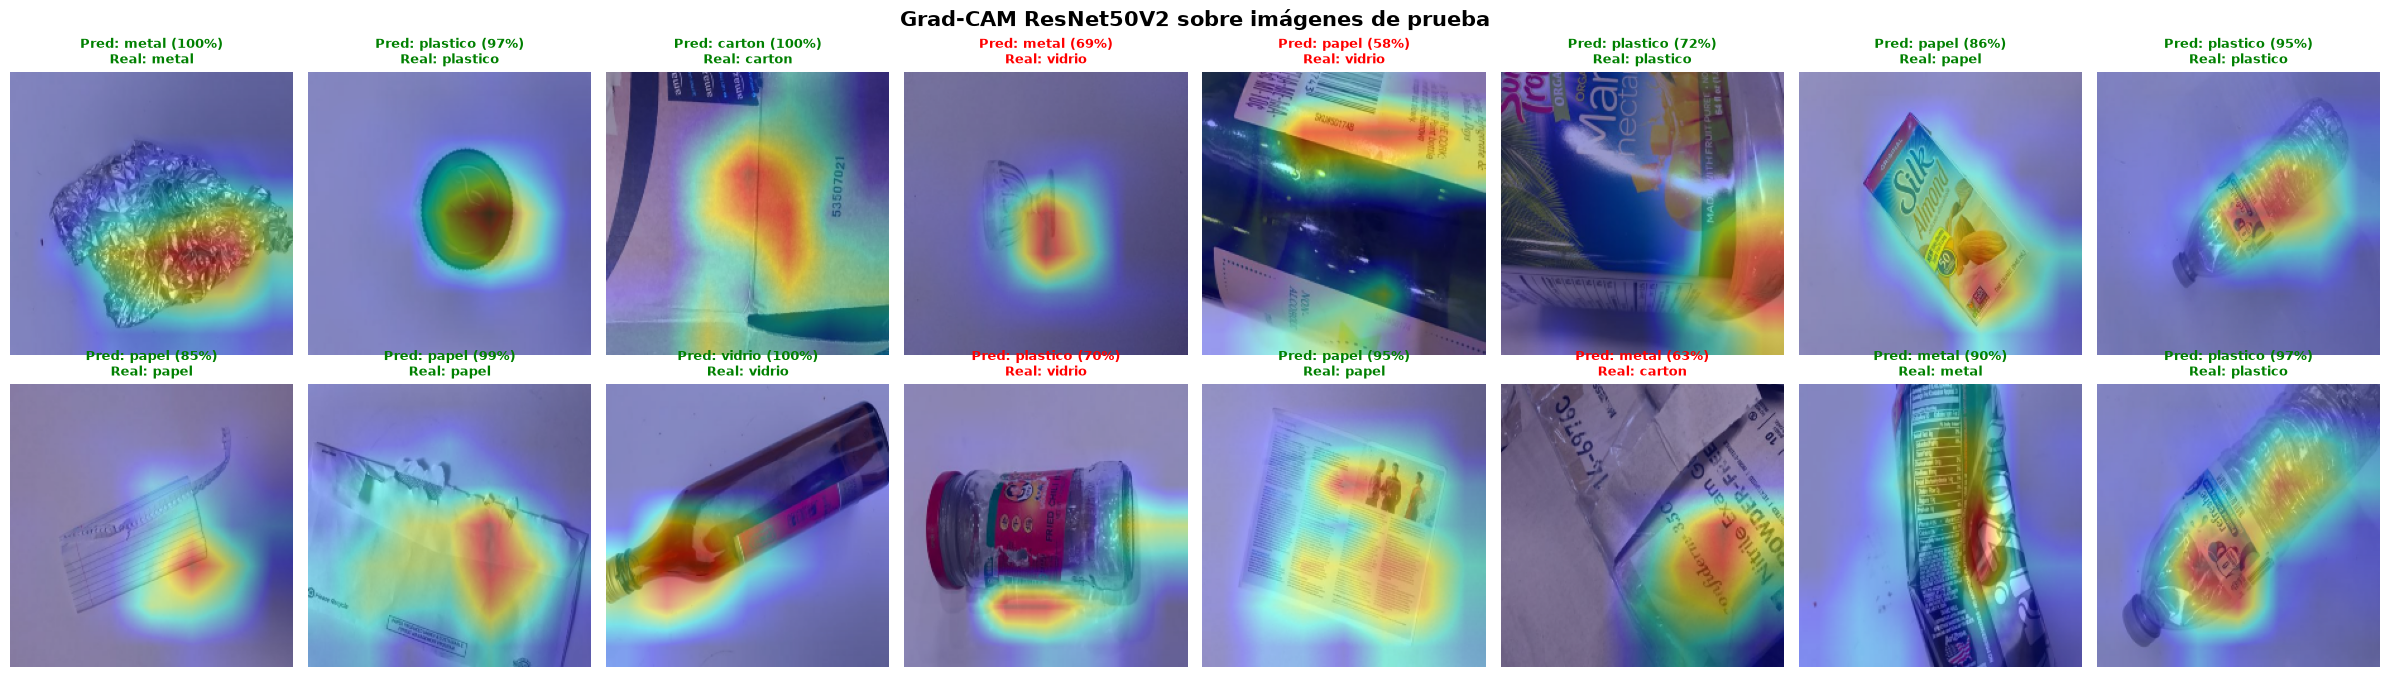

In [20]:
import cv2

def generar_gradcam_lote_resnet(modelo, lote_img_array, capa_identidad_nombre="Identity_Feature_Map"):
    grad_model = keras.Model(inputs=modelo.inputs,
                             outputs=[modelo.get_layer(capa_identidad_nombre).output, modelo.output])
    input_tensor = torch.tensor(lote_img_array, dtype=torch.float32)
    input_tensor.requires_grad = True

    conv_outputs, predicciones = grad_model(input_tensor, training=False)
    conv_outputs.retain_grad()

    # Puntaje de la clase predicha para cada imagen del lote (salida softmax multiclase)
    clases_pred = torch.argmax(predicciones, dim=1)
    clase_scores = predicciones[torch.arange(predicciones.shape[0]), clases_pred]
    clase_scores.backward(gradient=torch.ones_like(clase_scores))

    grads = conv_outputs.grad
    weights = torch.mean(grads, dim=(1, 2), keepdim=True)
    heatmaps = torch.relu(torch.sum(weights * conv_outputs, dim=-1))
    b = heatmaps.shape[0]
    max_vals = torch.max(heatmaps.view(b, -1), dim=1, keepdim=True)[0].view(b, 1, 1)
    heatmaps = heatmaps / (max_vals + 1e-8)
    return heatmaps.detach().cpu().numpy(), predicciones.detach().cpu().numpy()

for lote_imagenes, lote_etiquetas in test_dataset.take(1):
    lote_img_np, lote_lbl_np = lote_imagenes.numpy()[:16], lote_etiquetas.numpy()[:16]
heatmaps_lote, probs_lote = generar_gradcam_lote_resnet(model_transfer, lote_img_np)

fig, axes = plt.subplots(2, 8, figsize=(24, 7))
for i, ax in enumerate(axes.ravel()):
    img_orig = lote_img_np[i].astype("uint8")
    h, w, _ = img_orig.shape
    hm = np.uint8(255 * cv2.resize(heatmaps_lote[i], (w, h)))
    hm_color = cv2.cvtColor(cv2.applyColorMap(hm, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    ax.imshow(cv2.addWeighted(img_orig, 0.6, hm_color, 0.4, 0))
    p = probs_lote[i].argmax()
    ax.set_title(f"Pred: {CLASES[p]} ({probs_lote[i][p]*100:.0f}%)\nReal: {CLASES[lote_lbl_np[i]]}",
                 color="green" if p == lote_lbl_np[i] else "red", fontweight="bold", fontsize=9)
    ax.axis("off")
plt.suptitle("Grad-CAM ResNet50V2 sobre imágenes de prueba", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/gradcam.png", dpi=150); plt.show()